# Natural Language Processing
## Assignment 1 - Group 17

*_Adriano Machado (up202105352), Félix Martins (up202108837), Francisco da Ana (up202108762)_*  


### Overview
This assignment applies fundamental NLP techniques to solve a text classification problem without relying on deep learning architectures.

This notebook follows the following workflow:

1. **Data Exploration**: Understanding the dataset's characteristics through visualizations and statistical analysis
2. **Pre-processing Pipeline**: Implementing text normalization, cleaning, and feature extraction
3. **Feature Representation**: Experimenting with both sparse (e.g., TF-IDF) and dense (e.g., word embeddings) representations
4. **Model Selection**: Testing various classical ML algorithms (Naive Bayes, Logistic Regression, SVM, etc.)
5. **Evaluation & Refinement**: Measuring performance, analyzing errors, and iteratively improving the models


## Data Provenance and Characteristics

The [Polite Guard dataset](https://github.com/intel/polite-guard) is a specialized corpus developed by Intel for **politeness classification** in text. This dataset serves as the foundation for our NLP classification task.

### Data Sources and Collection

The dataset comprises three distinct components:
- **50,000 samples** generated using Few-Shot prompting
- **50,000 samples** generated using Chain-of-Thought (CoT) prompting
- **200 annotated samples** from corporate trainings (with personal identifiers removed)

The dataset is primarily synthetic, created using large language models (LLMs) to simulate customer service interactions across various sectors, such as finance, travel, food and drink, sports, etc. 


### Annotation Process

The dataset features a four-category classification system:
1. **Polite**: Text showing consideration, respect, and good manners with courteous phrases and friendly tone
2. **Somewhat Polite**: Generally respectful text lacking warmth or formality but maintaining a decent level of courtesy
3. **Neutral**: Straightforward and factual text without emotional undertones or specific attempts at politeness
4. **Impolite**: Disrespectful or rude text, often blunt or dismissive, showing lack of consideration


### Data Generation Process
- **Synthetic Data**: Generated through language models (Llama 3.1 8B-Instruct, Gemma 2 9B-It, Mixtral 8x7B-Instruct-v0.1) with specific instructions to create text matching the desired politeness category
- **Real Data**: The 200 real-world samples were collected from corporate trainings and manually annotated


### Data Distribution

The synthetic data is split into:
- Training set (80%)
- Validation set (10%)
- Test set (10%)

### Data Structure

Each example in the dataset contains:
- **text**: The input text string
- **label**: The classification label (polite, somewhat polite, neutral, impolite)
- **source**: The language model used for generation or "LMS" for corporate training samples
- **reasoning**: The rationale provided by the language model for the generated text (for synthetic samples)

## Exploratory Data Analysis

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.util import ngrams
from textblob import TextBlob
from sklearn.feature_extraction.text import CountVectorizer

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /Users/fpana/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /Users/fpana/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /Users/fpana/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/fpana/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to /Users/fpana/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [17]:
file_paths = {
    'train_cot': 'data/train/train_cot.csv',
    'train_few_shot': 'data/train/train_few_shot.csv',
    'val_cot': 'data/validation/val_cot.csv',
    'val_few_shot': 'data/validation/val_few_shot.csv',
    'test_cot': 'data/test/test_cot.csv',
    'test_few_shot': 'data/test/test_few_shot.csv',
    'test_LMs': 'data/test/test_lms.csv'
}

sns.set_palette("crest")

dataframes = {}
for name, path in file_paths.items():
    dataframes[name] = pd.read_csv(path)

In [18]:
for name, df in dataframes.items():
    shape_info = f"{name}: {df.shape} | Columns: {', '.join(df.columns)}"
    missing_info = f" | Missing Values: {df.isnull().sum().to_dict()}"
    
    duplicate_count = df.duplicated().sum()
    duplicates_info = f" | Duplicates: {duplicate_count}"
    
    print(shape_info)
    print(missing_info + duplicates_info)
    print()

train_cot: (40000, 4) | Columns: text, label, source, reasoning
 | Missing Values: {'text': 0, 'label': 0, 'source': 0, 'reasoning': 1} | Duplicates: 0

train_few_shot: (40000, 4) | Columns: text, label, source, reasoning
 | Missing Values: {'text': 0, 'label': 0, 'source': 0, 'reasoning': 40000} | Duplicates: 0

val_cot: (5000, 4) | Columns: text, label, source, reasoning
 | Missing Values: {'text': 0, 'label': 0, 'source': 0, 'reasoning': 0} | Duplicates: 0

val_few_shot: (5000, 4) | Columns: text, label, source, reasoning
 | Missing Values: {'text': 0, 'label': 0, 'source': 0, 'reasoning': 5000} | Duplicates: 0

test_cot: (5000, 4) | Columns: text, label, source, reasoning
 | Missing Values: {'text': 0, 'label': 0, 'source': 0, 'reasoning': 0} | Duplicates: 0

test_few_shot: (5000, 4) | Columns: text, label, source, reasoning
 | Missing Values: {'text': 0, 'label': 0, 'source': 0, 'reasoning': 5000} | Duplicates: 0

test_LMs: (200, 4) | Columns: text, label, source, reasoning
 | Mis

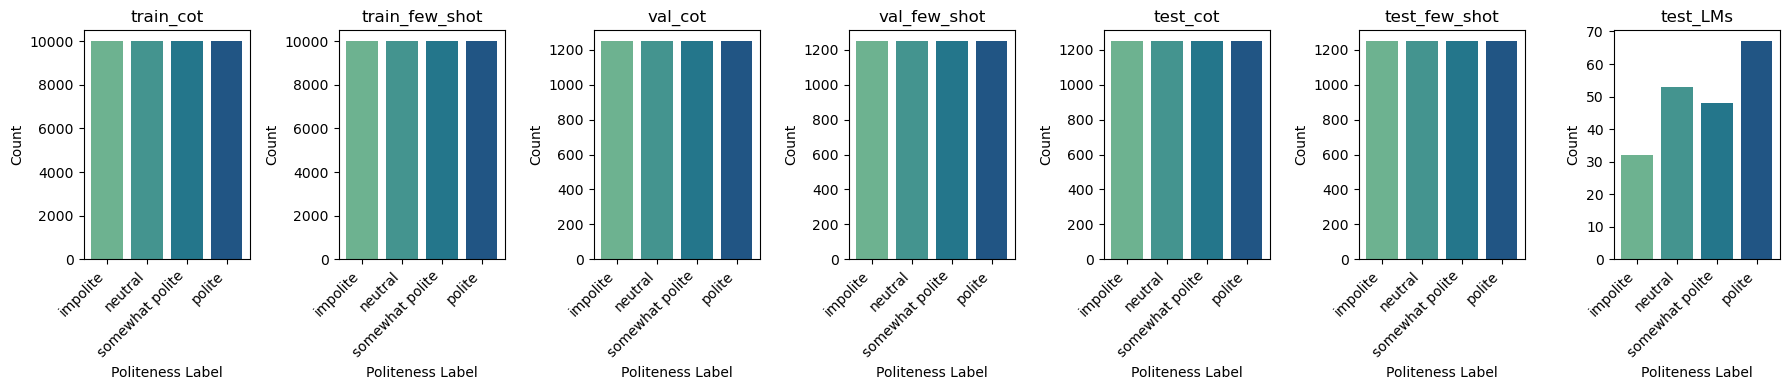

In [19]:
label_order = ['impolite', 'neutral', 'somewhat polite', 'polite']

plt.figure(figsize=(18, 4))
n_datasets = len(dataframes)
for i, (name, df) in enumerate(dataframes.items(), 1):
    if 'label' in df.columns:
        label_counts = Counter(df['label'].astype(str))
        labels = [l for l in label_order if l in label_counts]  
        counts = [label_counts[l] for l in labels if l in label_counts]
        
        plt.subplot(1, n_datasets, i)
        
        colors = sns.color_palette("crest", n_colors=len(labels))
        plt.bar(labels, counts, color=colors)
        
        plt.title(f'{name}')
        plt.xlabel('Politeness Label')
        plt.ylabel('Count')
        plt.xticks(rotation=45, ha='right')
    
plt.tight_layout()
plt.show()

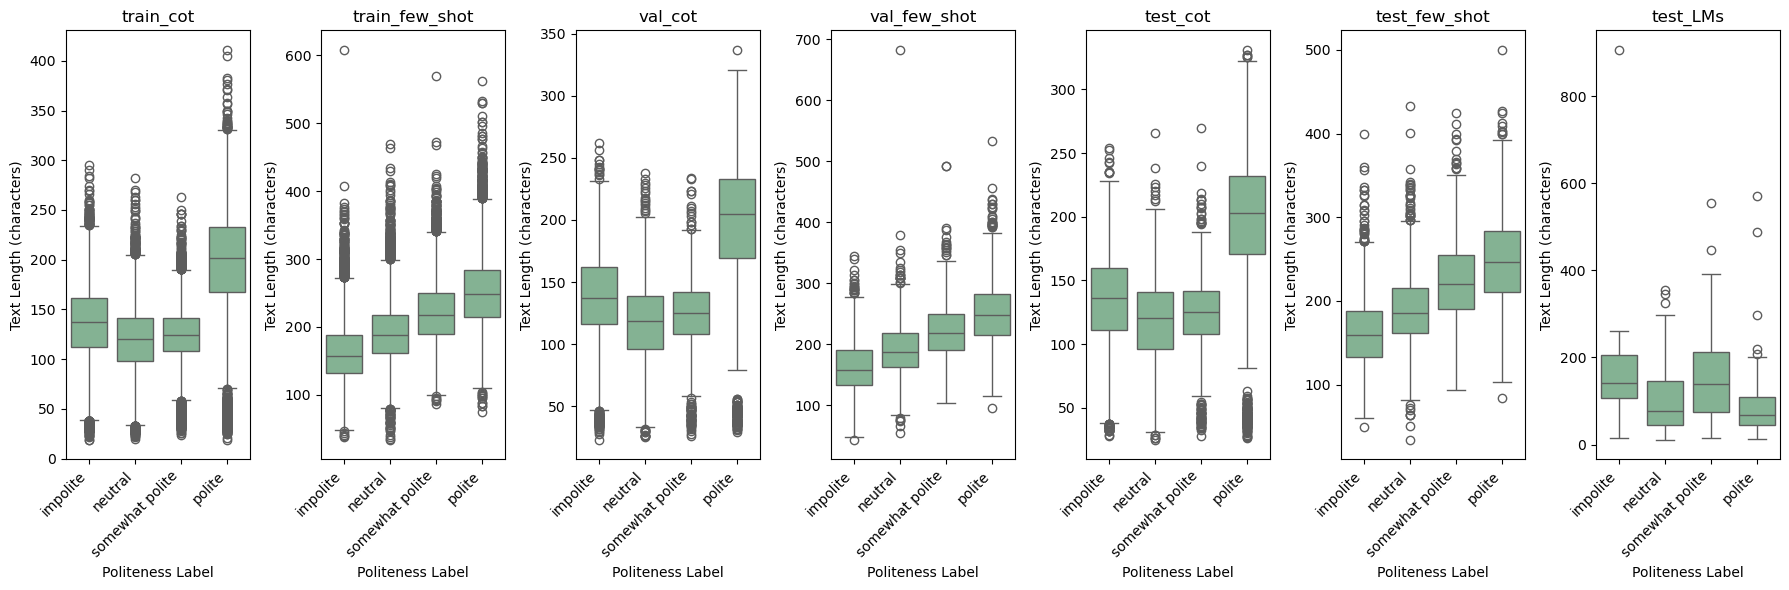

In [20]:
plt.figure(figsize=(18, 6))
for i, (name, df) in enumerate(dataframes.items(), 1):
    if 'label' in df.columns and 'text' in df.columns:
        text_lengths = df['text'].astype(str).fillna('').str.len()
        
        plt.subplot(1, n_datasets, i)
        sns.boxplot(data=df, x='label', y=text_lengths, order=label_order)
        plt.title(f'{name}')
        plt.xlabel('Politeness Label')
        plt.ylabel('Text Length (characters)')
        plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

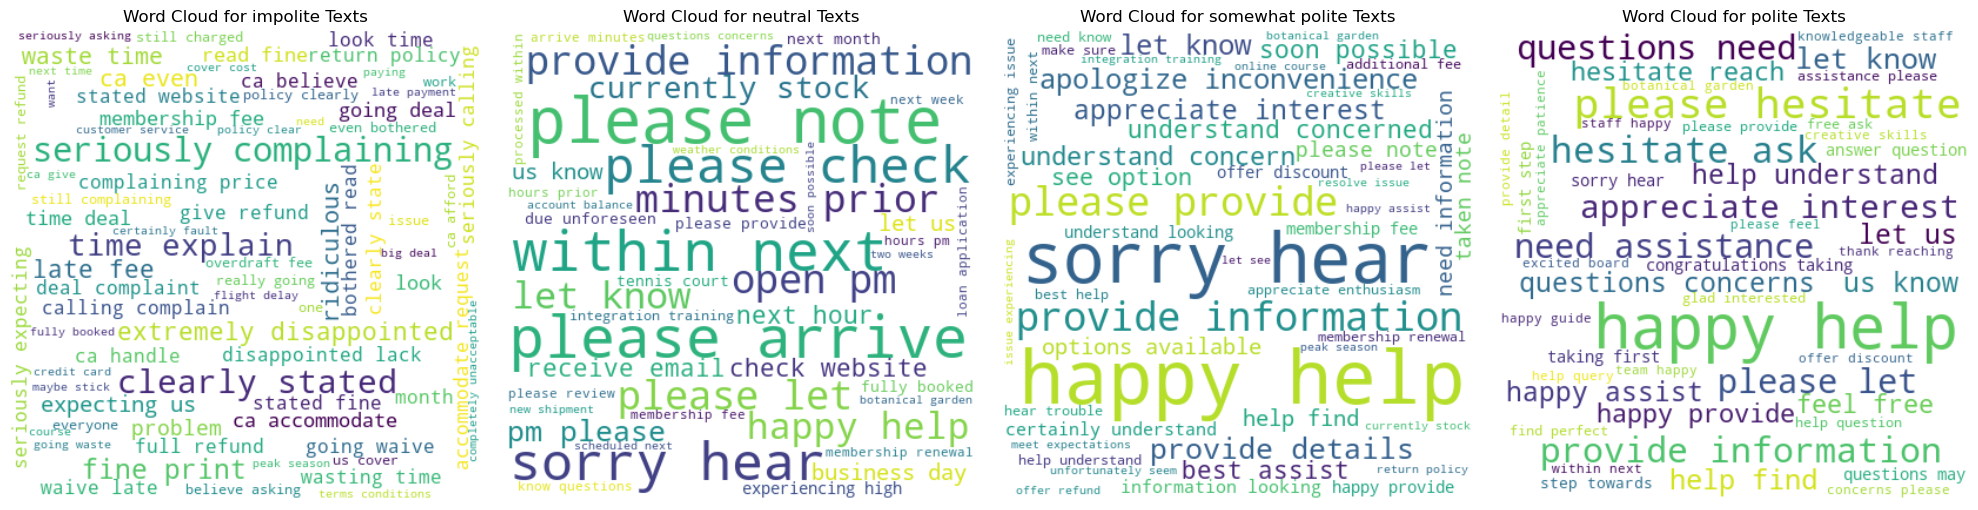

In [21]:

def generate_word_clouds(label_texts, label_order):
    num_labels = len(label_order)
    fig, axes = plt.subplots(1, num_labels, figsize=(5 * num_labels, 5)) 
    
    if num_labels == 1: 
        axes = [axes]

    for ax, label in zip(axes, label_order):
        if label_texts[label]: 
            stop_words = set(stopwords.words('english'))
            word_tokens = word_tokenize(' '.join(label_texts[label]))
            filtered_words = [word.lower() for word in word_tokens if word.lower() not in stop_words and word.isalnum()]
            
            wordcloud = WordCloud(width=400, height=400, background_color='white', min_font_size=10).generate(' '.join(filtered_words))

            ax.imshow(wordcloud, interpolation='bilinear')
            ax.set_title(f'Word Cloud for {label} Texts')
            ax.axis('off')

    plt.tight_layout()
    plt.show()

label_texts = {label: [] for label in label_order}
for name, df in dataframes.items():
    if 'label' in df.columns and 'text' in df.columns:
        for label in label_order:
            label_texts[label].extend(df[df['label'].astype(str) == label]['text'].dropna().tolist())


generate_word_clouds(label_texts, label_order)

In [22]:
def get_top_ngrams(texts, n=1, top_k=20):
    stop_words = set(stopwords.words('english'))
    all_ngrams = []
    
    for text in texts:
        tokens = [token.lower() for token in word_tokenize(text) 
                 if token.isalnum() and token.lower() not in stop_words]
        
        text_ngrams = list(ngrams(tokens, n))
        all_ngrams.extend(text_ngrams)
    
    ngram_freq = Counter(all_ngrams)
    
    return ngram_freq.most_common(top_k)

In [23]:
def plot_top_ngrams(label_texts, label_order, n=1, top_k=15):
    fig, axes = plt.subplots(1, len(label_order), figsize=(6 * len(label_order), 6))
    
    for i, label in enumerate(label_order):
        ax = axes[i]
        if not label_texts[label]:
            ax.text(0.5, 0.5, f"No data for {label}", ha='center', va='center')
            ax.set_title(f"Top {top_k} {n}-grams for {label}")
            ax.axis('off')
            continue
            
        top_ngrams = get_top_ngrams(label_texts[label], n, top_k)
        
        if n > 1:
            labels = [' '.join(ng[0]) for ng in top_ngrams]
        else:
            labels = [ng[0][0] for ng in top_ngrams]
            
        values = [ng[1] for ng in top_ngrams]
        
        bars = ax.barh(range(len(labels)), values, color=sns.color_palette("crest", n_colors=1)[0])
        ax.set_yticks(range(len(labels)))
        ax.set_yticklabels(labels)
        ax.invert_yaxis() 
        ax.set_title(f"Top {top_k} {n}-grams for {label}")
        
        for bar in bars:
            width = bar.get_width()
            ax.text(width + 0.5, bar.get_y() + bar.get_height()/2, f"{int(width)}", 
                    ha='left', va='center')
    
    plt.tight_layout()
    return fig

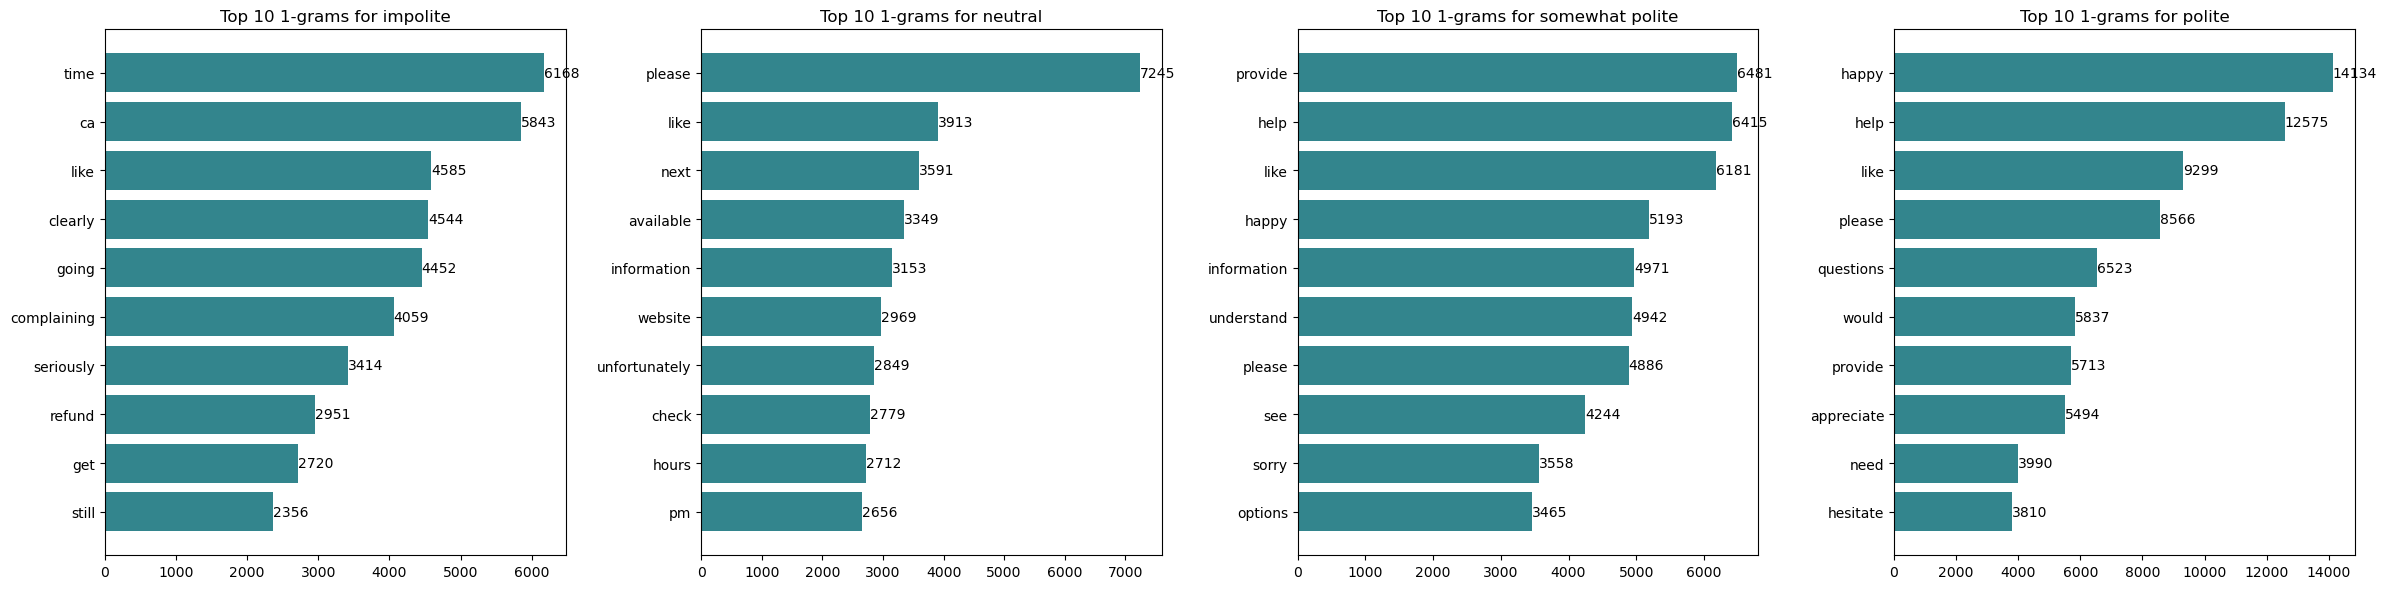

In [24]:
unigram_fig = plot_top_ngrams(label_texts, label_order, n=1, top_k=10)
plt.show()

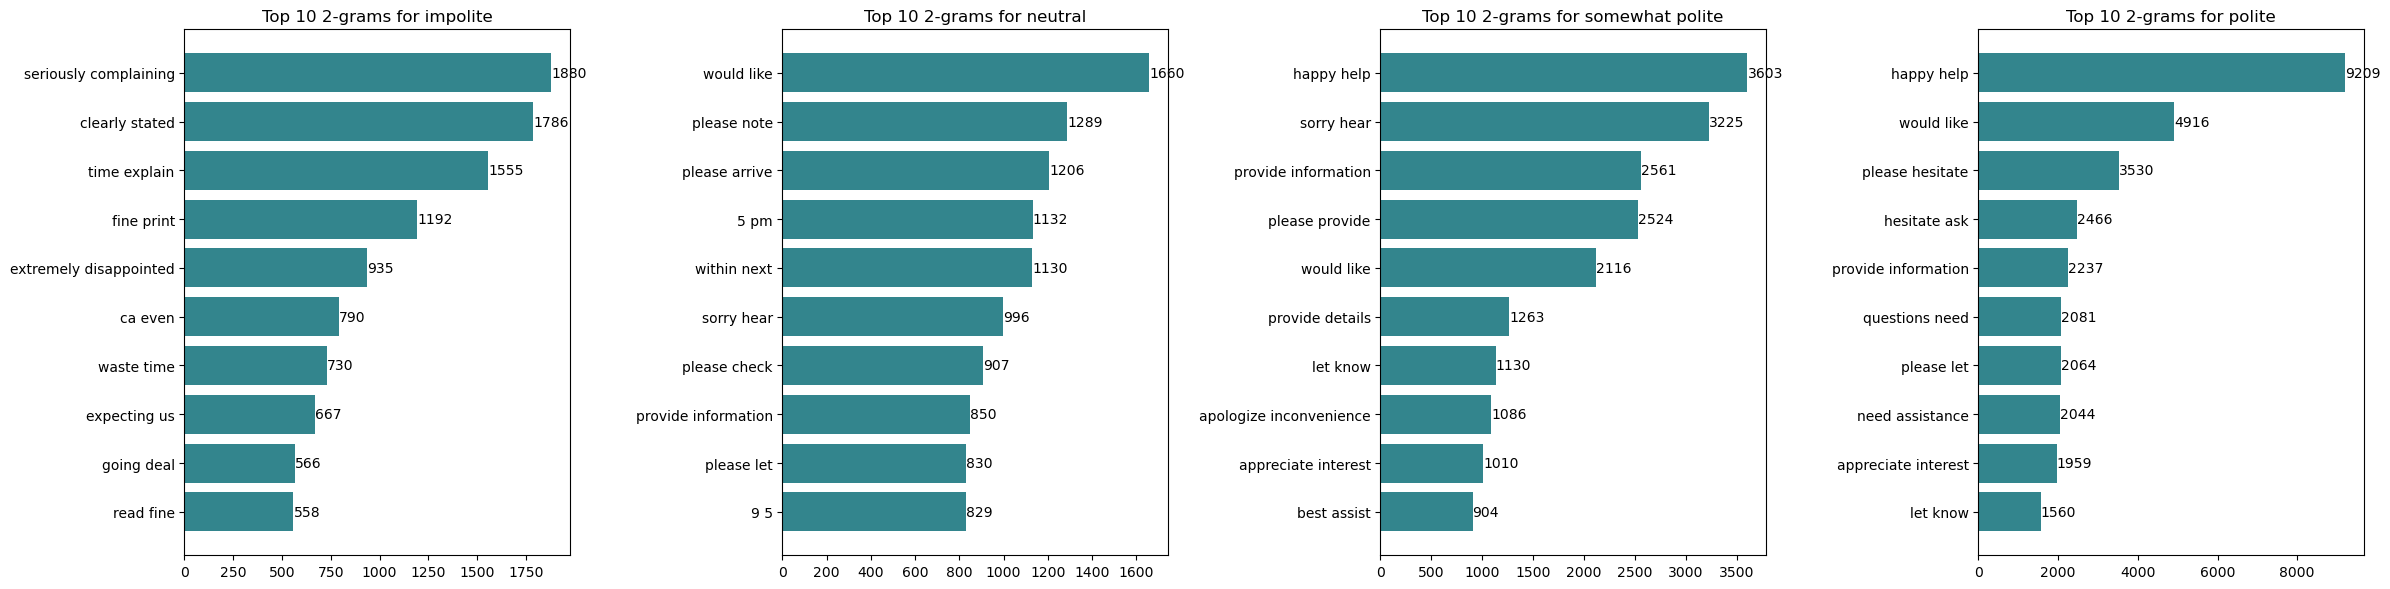

In [25]:
unigram_fig = plot_top_ngrams(label_texts, label_order, n=2, top_k=10)
plt.show()

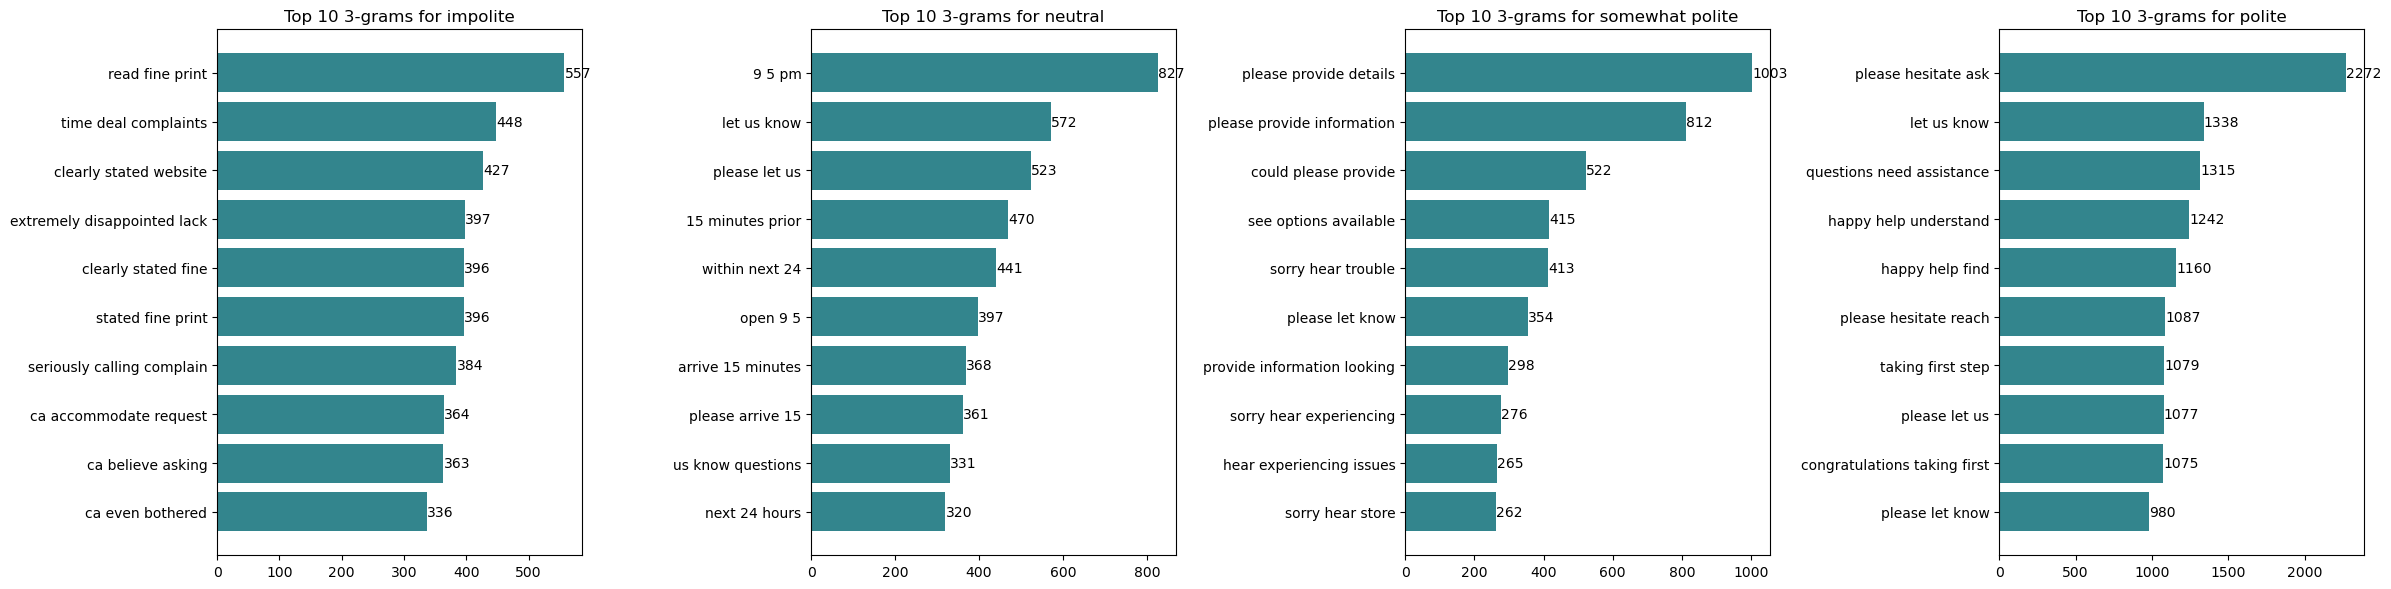

In [26]:
unigram_fig = plot_top_ngrams(label_texts, label_order, n=3, top_k=10)
plt.show()

In [27]:
def analyze_sentiment_subjectivity_for_plotting(df, label_order):
    sentiment_data_plot = {}
    for label in label_order:
        label_df = df[df['label'].astype(str) == label]['text'].dropna()
        polarities = []
        subjectivities = []
        for text in label_df:
            blob = TextBlob(text)
            polarities.append(blob.sentiment.polarity)
            subjectivities.append(blob.sentiment.subjectivity)
        sentiment_data_plot[label] = {'polarity': polarities, 'subjectivity': subjectivities}
    return sentiment_data_plot


In [28]:
def plot_combined_sentiment_analysis(sentiment_results, label_order):
    datasets = list(sentiment_results.keys())
    num_datasets = len(datasets)
    
    # Create grid: 2 rows (polarity/subjectivity) × N datasets
    fig, axes = plt.subplots(2, num_datasets, 
                           figsize=(4.5 * num_datasets, 8),
                           squeeze=False) 
    fig.suptitle('Sentiment Analysis Comparison', y=1.02)

    palette = sns.color_palette("crest", n_colors=len(label_order))

    for col_idx, dataset_name in enumerate(datasets):
        data = sentiment_results[dataset_name]
        
        polarity_data = []
        subjectivity_data = []
        plot_labels = []

        for label in label_order:
            if data.get(label):
                polarity_data.extend(data[label]['polarity'])
                subjectivity_data.extend(data[label]['subjectivity'])
                plot_labels.extend([label] * len(data[label]['polarity']))

        polarity_df = pd.DataFrame({'Label': plot_labels, 'Polarity': polarity_data})
        subjectivity_df = pd.DataFrame({'Label': plot_labels, 'Subjectivity': subjectivity_data})

        # --- Polarity Plot (Top Row) ---
        ax_pol = axes[0, col_idx]
        if not polarity_df.empty:
            sns.boxplot(x='Label', y='Polarity', data=polarity_df, 
                        hue='Label', palette=palette, width=0.6, 
                        order=label_order, ax=ax_pol, legend=False)
            ax_pol.set_title(f'{dataset_name}\nPolarity', fontsize=12)
            ax_pol.set_ylabel('Polarity Score')
            ax_pol.tick_params(axis='x', labelrotation=45)
            ax_pol.grid(True, alpha=0.3, axis='y')
        else:
            ax_pol.text(0.5, 0.5, "No polarity data", 
                       ha='center', va='center')
            ax_pol.axis('off')

        # --- Subjectivity Plot (Bottom Row) ---
        ax_sub = axes[1, col_idx]
        if not subjectivity_df.empty:
            sns.boxplot(x='Label', y='Subjectivity', data=subjectivity_df,
                        hue='Label', palette=palette, width=0.6,
                        order=label_order, ax=ax_sub, legend=False)
            ax_sub.set_title(f'{dataset_name}\nSubjectivity', fontsize=12)
            ax_sub.set_ylabel('Subjectivity Score')
            ax_sub.tick_params(axis='x', labelrotation=45)
            ax_sub.grid(True, alpha=0.3, axis='y')
        else:
            ax_sub.text(0.5, 0.5, "No subjectivity data",
                       ha='center', va='center')
            ax_sub.axis('off')

    plt.tight_layout()
    plt.show()

In [29]:
sentiment_plot_results = {}
for name, df in dataframes.items():
    if 'label' in df.columns and 'text' in df.columns:
        print(f"\nProcessing: {name}")
        sentiment_plot_results[name] = analyze_sentiment_subjectivity_for_plotting(df, label_order)


Processing: train_cot

Processing: train_few_shot

Processing: val_cot

Processing: val_few_shot

Processing: test_cot

Processing: test_few_shot

Processing: test_LMs


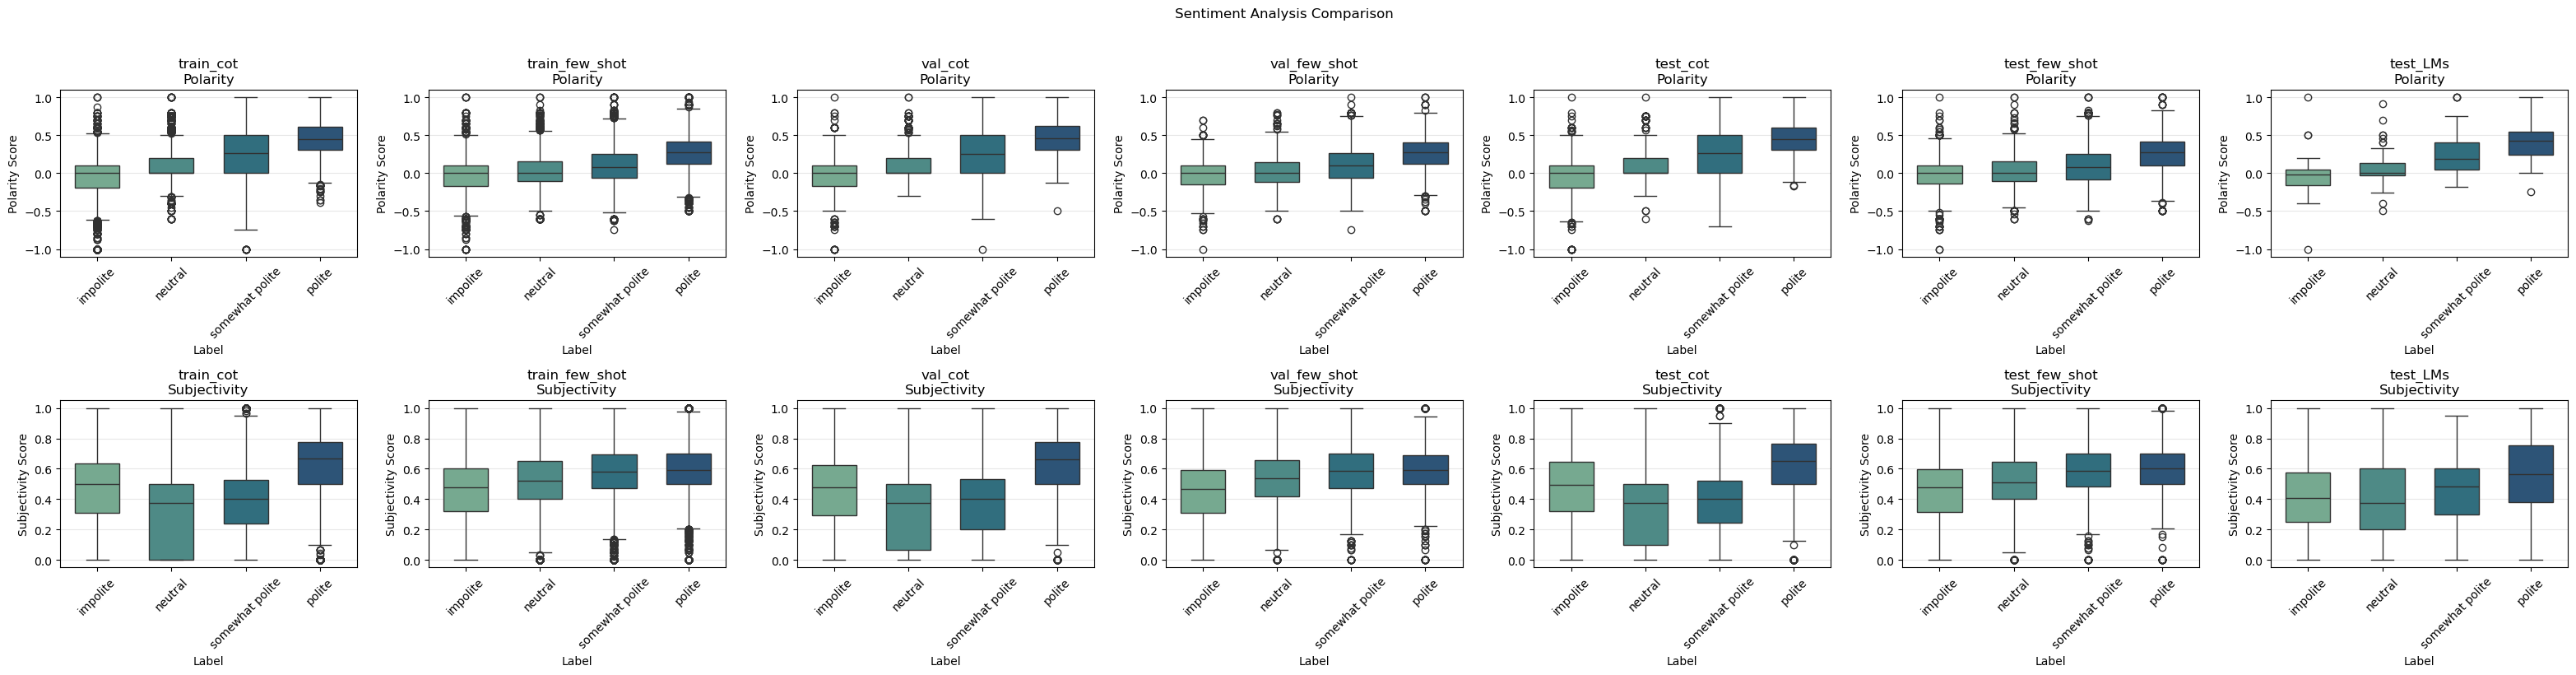

In [30]:
if sentiment_plot_results:
    plot_combined_sentiment_analysis(sentiment_plot_results, label_order)
else:
    print("No valid datasets found for sentiment analysis")

## Preprocessing and feature representation techniques

**Feature extraction**
- Bag of words (n=1 without stop words, n=2 with stop word)
- TF-IDF
- (Word embeddings)

**Data preprocessing**
- Tokenization
- Case folding (lowercasing)
- Removing punctuation and special characters
- Lemmatization

In [31]:
import nltk
from nltk import word_tokenize, pos_tag
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
import re

# Initialize lemmatizer
lemmatizer = WordNetLemmatizer()
sw = set(stopwords.words('english'))

# Function to convert NLTK POS tags to WordNet POS tags
def get_wordnet_pos(nltk_tag):
    """
    Convert NLTK POS tags to WordNet POS tags.

    Parameters:
        nltk_tag (str): Part-of-speech tag in Penn Treebank format

    Returns:
        wordnet-POS-constant: The corresponding WordNet POS tag
    """
    tag_to_wordnet = {
        'J': wordnet.ADJ,
        'V': wordnet.VERB,
        'N': wordnet.NOUN,
        'R': wordnet.ADV
    }
    # Default is noun
    return tag_to_wordnet.get(nltk_tag[0], wordnet.NOUN)

def preprocess_text(review, include_sw=False):
    """
    Preprocess text data for NLP tasks:
    1- Removes non-alphabetic characters
    2- Converts text to lowercase
    3- Tokenizes text
    4- Removes stopwords (optional)
    5- Uses lemmatization with POS tagging.

    Parameters:
        text (str): Input text to be preprocessed
        include_sw (bool): Whether to include stopwords in the result
                           Default is False (stopwords are removed)
    Returns:
        str: Preprocessed text with lemmatized words joined by spaces
    """
    # Remove non-alphabetic characters
    review = re.sub('[^a-zA-Z]', ' ', review)  # TODO: include (or not) numbers
    review = review.lower()

    # Tokenize
    words = word_tokenize(review)

    # POS (Part-of-speech) tagging
    tagged_words = pos_tag(words)

    # Lemmatize with POS tags
    lemmatized_words = [lemmatizer.lemmatize(word, get_wordnet_pos(pos_tag)) 
                        for word, pos_tag in tagged_words 
                        if word not in sw or include_sw]
    return ' '.join(lemmatized_words)

In [32]:
print(dataframes["train_cot"]["text"][0])
print(preprocess_text(dataframes["train_cot"]["text"][0]))

Your flight has been rescheduled for 10:00 AM tomorrow. Please check the airport's website for any updates or changes.
flight reschedule tomorrow please check airport website update change


In [33]:
def preprocess_dataframe(dataframes, feature, target):
    """
    Applies the text preprocessing function to the specified feature column in the dataframes.clear

    Parameters:
        dataframes (list): A list of pandas DataFrames
        feature (str): The name of the feature column to preprocess
        target (str): The name of the target column
    
    Returns:
        pd.DataFrame: A concatenated DataFrame with the preprocessed feature and target columns from all input DataFrames
    """
    result = pd.DataFrame()
    for df in dataframes:
        df[feature] = df[feature].apply(preprocess_text)
        result = pd.concat([result, df[[feature, target]]])
    return result

def extract_features(dataframes, feature, target, feature_extractor):
    """
    Extracts features from the specified feature column in the dataframes using a given feature extractor method.
    For example, the feature extractor could be a TF-IDF vectorizer or a Bag-of-Words algorithm.

    Parameters:
        dataframes (list): A list of pandas DataFrames
        feature (str): The name of the feature column to extract features from
        target (str): The name of the target column
        feature_extractor (callable): A function that takes a list of texts and returns a list of feature vectors

    Returns:
        pd.DataFrame: A concatenated DataFrame with the extracted features and target columns from all input DataFrames
    """
    cleaned_data = preprocess_dataframe(dataframes, feature, target)  # This is a DataFrame
    feature_matrix = feature_extractor.fit_transform(cleaned_data[feature])
    feature_df = pd.DataFrame(feature_matrix.toarray(), columns=feature_extractor.get_feature_names_out())
    feature_df[target] = cleaned_data[target].values
    return feature_df

In [36]:
bag_of_words = CountVectorizer()
train_data = extract_features([dataframes['train_cot'], dataframes['train_few_shot']], 'text', 'label', bag_of_words)
val_data = extract_features([dataframes['val_cot'], dataframes['val_few_shot']], 'text', 'label', bag_of_words)

In [38]:
print(train_data.shape)
print(val_data.shape)

(80000, 5959)
(10000, 3706)


## Classification Models

**ML Algorithms**
- Naive Bayes
- Logistic Regression
- SVM